## Superstore Profitability Analysis
### Overview
This is a superstore transaction dataset. it contains comprehensive collection of sales, customer, and product data for analysis. Includes columns like Order Date, Ship Date, Customer ID, Product Category, Sales, Quantity, Discount, and Profit. Valuable resource for exploring trends and optimizing business strategies. 
the dataset provides an opportunity to examine the impact of various factors such as discounts, geographical locations, and product categories on profitability. By analyzing this dataset, businesses can uncover actionable insights for optimizing pricing strategies, supply chain management, and customer engagement.

### Objective
Identify the primary operational and pricing factors associated with negative profit and high-margin transactions to inform pricing and discount strategy.

The driving forces behind profit could be:
* category
* quantity
* region
* segmentation 
* discount
* sub-category
* ship mode

I will investigate these cloumns to find out how they affect the profit of the superstore

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean

In [2]:
df=pd.read_csv('Superstore.csv', encoding='windows-1252')

In [3]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#### the initial data types were mostly objects and didn't reflect the real data types, I converted them below to their respective data types


In [7]:
df['Category']=df['Category'].astype('category')
df['Sub-Category']=df['Sub-Category'].astype('category')
df['Order Date']=pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date']=pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
df['Segment']=df['Segment'].astype('category')
df['Region']=df['Region'].astype('category')
df['Ship Mode']=df['Ship Mode'].astype('category')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   category      
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   category      
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   category      
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   category      
 15  Sub-Category   9994 n

In [9]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

#### Below starts the univariate EDA, I will get to know the variables one by one first

In [11]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


##### the objective is to see what drives profit so I will investigate the columns below for better understanding
* Profit
* sales
* category
* quantity
* discount
* region
* segment
* ship mode


I will start with Profit (target variable) itself. profit is one of business KPIs that indicate whether a business is doing good or not.
in this superstore, I will investigate the Profit itself

In [12]:
df['Profit'].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

In [13]:
(df['Profit'] >0).mean() * 100

np.float64(80.62837702621573)

In [14]:
(df['Profit'] < 0 ).mean() *100

np.float64(18.721232739643785)

In [15]:
(df['Profit']==0).mean()*100

np.float64(0.6503902341404842)

In [16]:
df['Profit'].var()

54877.79805537903

In [17]:
q1, q3=np.percentile(df['Profit'], [25, 75])
IQR=q3 - q1
lower_bound= q1 - 1.5 * IQR
upper_bound=q3 + 1.5 * IQR
outliers=df[(df['Profit'] < lower_bound ) | (df['Profit'] > upper_bound)]
len(outliers)

1881

In [18]:
low_out = df[df['Profit'] < lower_bound]
high_out = df[df['Profit'] > upper_bound]
print(f"Low outliers: {len(low_out)} ({len(low_out)/len(df)*100:.1f}%)")
print(f"High outliers: {len(high_out)} ({len(high_out)/len(df)*100:.1f}%)")

Low outliers: 604 (6.0%)
High outliers: 1277 (12.8%)


In [19]:
# calculating the trimmed mean
trimmed_profit=trim_mean(df['Profit'], proportiontocut=0.10)
trimmed_profit

np.float64(15.801032066033017)

In [20]:
df['Profit'].skew()

np.float64(7.561431562468343)

In [21]:
df['Profit'].kurt()

np.float64(397.1885145524141)

Text(0, 0.5, 'Density')

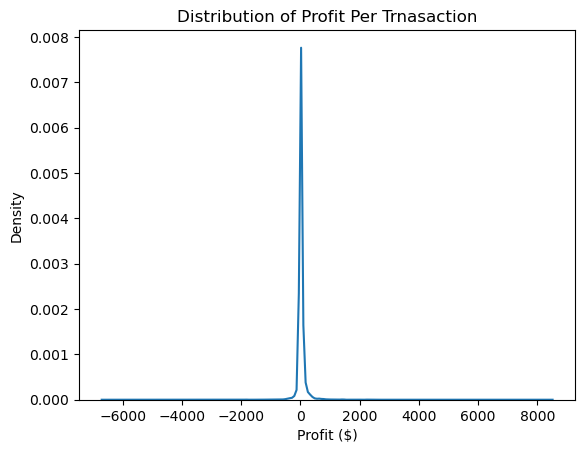

In [22]:
sns.kdeplot(x=df['Profit'])
plt.title('Distribution of Profit Per Trnasaction')
plt.xlabel('Profit ($)')
plt.ylabel('Density')

this kdeplot demonstrates that the profit is right skewness it also shows extreme concentration where there is very small/near-zero profit and how it's centered at zero which is interesting seeing the fact that the data is spread out (the std being almost 8.5 times higher than the mean), we can expect high variability and enormous fluctuations from transaction to transaction. I will investigate more with boxplot to make sure

Text(0.5, 0, 'Profit ($)')

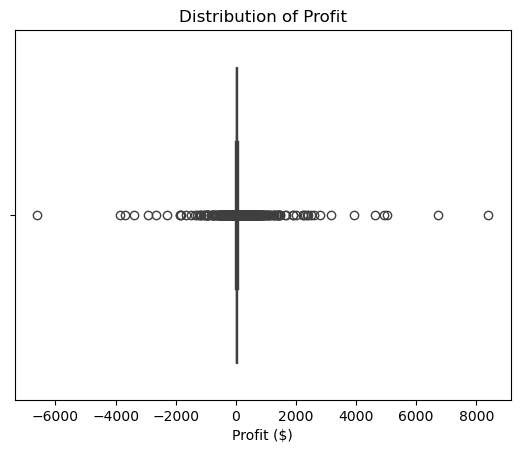

In [23]:
sns.boxplot(x=df['Profit'])
plt.title('Distribution of Profit')
plt.xlabel('Profit ($)')

from the above, I could see that the average profit is $28, the maximum profit attained is $8400 with the loss being - $6600. the median being $8, This goes to show that most transactions make modest to negative profits. this shows that the profit is positively skewed with heavy-tailed distribution with extreme outliers. the kurtosis being high demonstrates extreme leptokurtosis indicating high concentration of risk in outliers.. this goes to show that while the superstore have big losses, the big wins tend to be higher in magnitude.  

The 10% trimmed mean of Profit is $15.8, compared to the regular mean of $28 and the median of $8.
This indicates that extreme high-profit orders (approximately the top 10%) significantly inflate the overall average. After trimming these extremes, the typical profit per order is closer to $15–16, though still higher than the median due to remaining positive skew in the central portion of the data.
For describing 'average' or 'typical' order profitability, the trimmed mean or median provide more representative figures than the regular mean. This reinforces that profitability is outlier-driven

from a business perspective, I am looking at a data thats high volume and low margin, where the superstore is processing small transactions where the profit is negligible. While small transactions dominate volume, profitability is disproportionately driven by larger, high-margin orders.

* Near-Zero Margin Transactions - Only 0.65% of transactions are break-even, indicating a highly polarized pricing strategy: we are either making a clear profit or taking a definitive loss, with very little middle ground.

* Negative Margin Exposure - While losses occur in only 18.7% of cases, the magnitude of individual losses is extreme with some exceeding $-\$6,000$. This suggests that our losses are not just 'cost of doing business' but are likely driven by deep discounting or high-cost returns on expensive items.

* Profitability Rate - The business maintains an 80.6% profitability rate across all transactions. While the vast majority of sales are in the black, the operational focus should shift toward the 18.7% of transactions that are currently eroding total margin.

* Opportunity: Reduce deep discounts/losses on high-value items to protect margins.


### the next one is sales, I will investigate the Sales column independently

In [24]:
df['Sales'].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [25]:
df['Sales'].median()

54.489999999999995

In [26]:
(df['Sales'].mean() > (2 * df['Sales'].median()))

np.True_

although the average sales is $230 and the median is only $54. this means most orders are small and small numbers of very large orders drive the majority of revenue. since the average sales very noticeably higher than the median, I will have to perform trimmed average. but first, lets find out how much of an outlier this data have.

In [27]:
q1, q3=np.percentile(df['Sales'], [25, 75])
iqr=q3-q1
lower=q1 - 1.5 * iqr
upper=q3 + 1.5 * iqr
low_sales_out=df[df['Sales'] < lower]
high_sales_out=df[df['Sales']> upper]
print(f'Lower Sales outliers: {(len(low_sales_out) / len(df)) * 100} %')
print(f'higher sales outliers: {(len(high_sales_out)/ len(df)) * 100}')

Lower Sales outliers: 0.0 %
higher sales outliers: 11.677006203722232


<Axes: xlabel='Sales', ylabel='Density'>

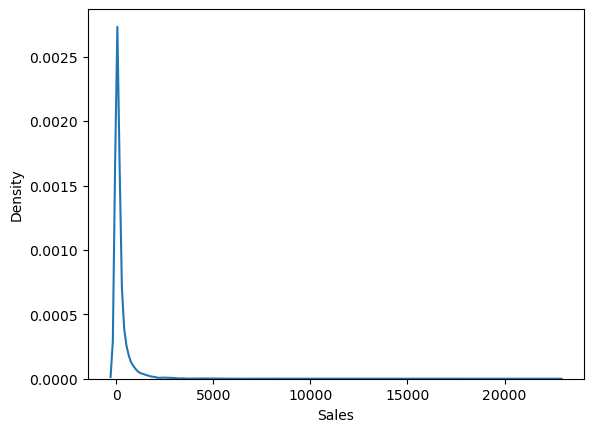

In [28]:
sns.kdeplot(x=df['Sales'])

In [29]:
df['Sales'].skew()

np.float64(12.97275234181623)

In [30]:
df['Sales'].kurt()

np.float64(305.311753246823)

In [31]:
trimmed_sales=trim_mean(df['Sales'], 0.10)
trimmed_sales

np.float64(113.18491028014007)

from the above skewness and kurtosis also the kdeplot, I could tell the sales column is positively skewed(skew = 12.97 and mean > median) and the kurtosis is 305.9 which is high and peaked and heavy tailed. it showed that extreme sales pulled the value. the mean being greater than median makes me to use the median instead of the mean.

The above insights show the sales distribution is strongly right-skewed with no low outliers (0%) but a substantial number of high outliers(11.7%).
* No order have unusually low sales relative to the central bulk.
* However, ~12% of transactions are flagged as outliers this shows larger-than-typical transactions.

from the trimmed average (10% trim), it can be seen that the average sales is $113, contrary to the regular average which is $230. this shows that the high outtliers pulled the average high outliers.

* The superstore is business where 11.7% of transactions create the majority of the volume. However, given the 18.7% loss rate, I must investigate if I am over-discounting to chase these high-value sales. 
## The last bullet point isnot proved yet!!!!!!!!!! come back and check if those outliers drive the profits!!


### the next one is Category, I will look at the categories involved snd how they might contribute to the overall profit

In [32]:
df['Category'].describe(include=['O'])

count                9994
unique                  3
top       Office Supplies
freq                 6026
Name: Category, dtype: object

In [33]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [34]:
df['Category'].agg(['mode'])

,mode
0,Office Supplies


In [35]:
proportions=df['Category'].value_counts(normalize=True)
perc=proportions*100

In [36]:
perc

Category
Office Supplies    60.296178
Furniture          21.222734
Technology         18.481089
Name: proportion, dtype: float64

In [37]:
cumm=proportions.cumsum() * 100
cumm

Category
Office Supplies     60.296178
Furniture           81.518911
Technology         100.000000
Name: proportion, dtype: float64

<Axes: xlabel='count', ylabel='Category'>

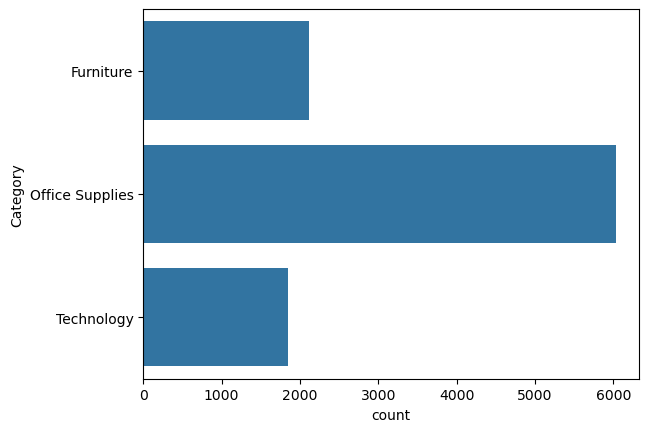

In [38]:
sns.countplot(data=df, y='Category')


The distribution of ``Category`` shows that ``Office Supplies`` represents 60.2% of transactions, followed by ``Furniture`` at 21%.

This indicates a concentration of operational activity in ``Office Supplies``.

Although ``Office Supplies`` dominates volume, its contribution to profit is unclear for now.

**Business Implications and Insights**
* **Operational Volume** - most of the transaction volume comes from ``Office Supplies`` which means low-complexity and everyday items are mostly interacted.
* **Risk Concentration** - ~ 81% of the transaction is from two categories (``Office Supplies`` and `Furniture`) which indicates there would be a *Operational dependency risk*. any disrupt in supply chain, inventory of these two categories might impact the majority of the transaction

<!-- This concentration may create:

- Operational dependency risk
- Revenue concentration risk
- Opportunity for targeted optimization -->

*The product category mix is **heavily weighted toward Office Supplies** (60% of orders). Furniture and Technology play secondary roles. While this provides stable order flow, profitability leadership is not guaranteed by volume — deeper analysis of margins and profit by category is required.*

from the above analysis on Category, we can see that there is a class imbalance with office supplies covering 60% of the transaction count with furniture coming in second with 21% and technology coming in last with 18%. this shows there is a mild class imbalance. 

I also checked for cardinality and data integrity in which I found that there is no high cardinality, there is a data integrity. 

the last thing I checked was Pareto Table in which to find out which of the categories have 80% and more activity. I found out the two categories having 80% activity are office supplies and furniture. whether these columns have actual contribute to profit or loss, I will find out in Bivariate analysis.

### next is Quantity. 

In [39]:
df['Quantity'].describe()

count    9994.000000
mean        3.789574
std         2.225110
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64

In [40]:
3 * 1.5

4.5

In [41]:
df['Quantity'].median()

3.0

In [42]:
df['Quantity'].mode()

0    3
Name: Quantity, dtype: int64

In [43]:
df['Quantity'].skew()

np.float64(1.2785447527223421)

In [44]:
df['Quantity'].kurtosis()

np.float64(1.9918893664821322)

<Axes: xlabel='Quantity', ylabel='Count'>

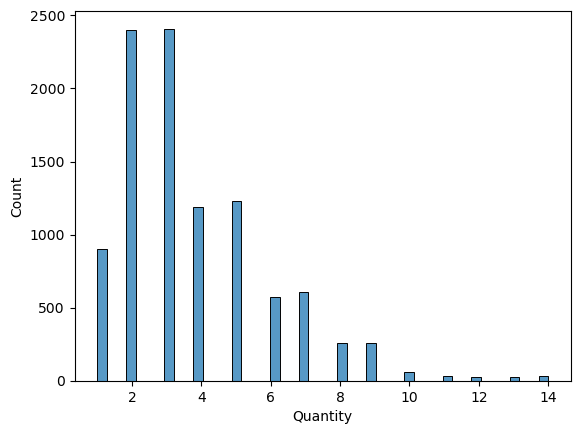

In [45]:
sns.histplot(x=df['Quantity'])

<Axes: xlabel='Quantity', ylabel='Density'>

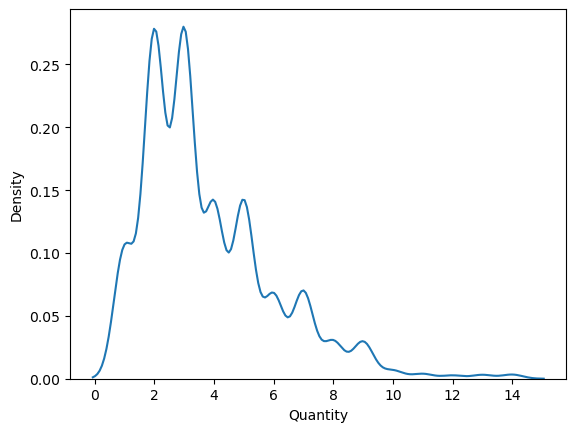

In [46]:
sns.kdeplot(x=df['Quantity'])

<Axes: xlabel='Quantity'>

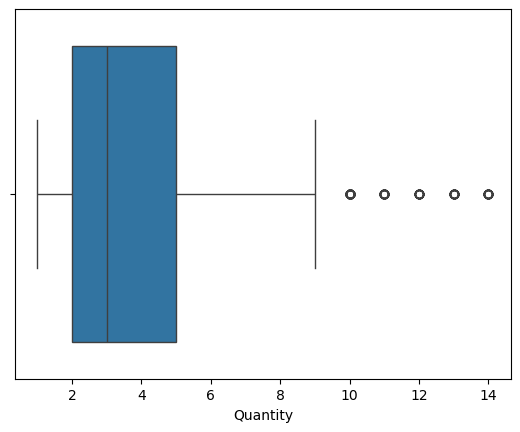

In [47]:
sns.boxplot(x=df['Quantity'])

from the above analysis for Quantity, it shows Quantity is slightly positively skewed and leptokurtic. it also highighes that the average quantity is 3.7 and the median quantity is 3. and the maximum quantity is 14. 

during the boxplot, I saw that the values above 10 are considered outliers. and also i didnt actually find something useful from this. whether it have inversely proportional or proportional relationship with profit is to be studied in bivariate section

### next is discount

In [48]:
df['Discount'].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [49]:
df['Discount'].mean() * 100

np.float64(15.620272163297976)

In [50]:
df['Discount'].median()

0.2

In [51]:
df['Discount'].median() * 100

20.0

In [52]:
df['Discount'].skew()

np.float64(1.6842947474238648)

<Axes: xlabel='Discount'>

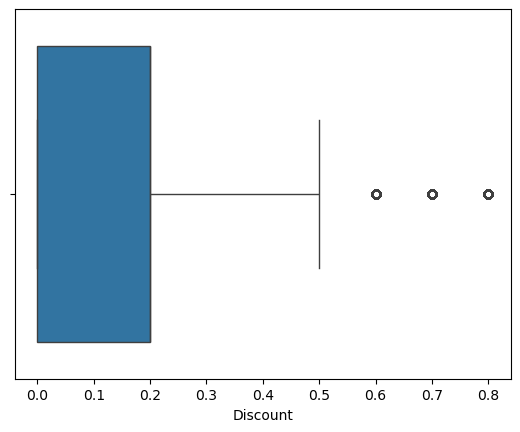

In [53]:
sns.boxplot(x=df['Discount'])

<Axes: xlabel='Discount', ylabel='Count'>

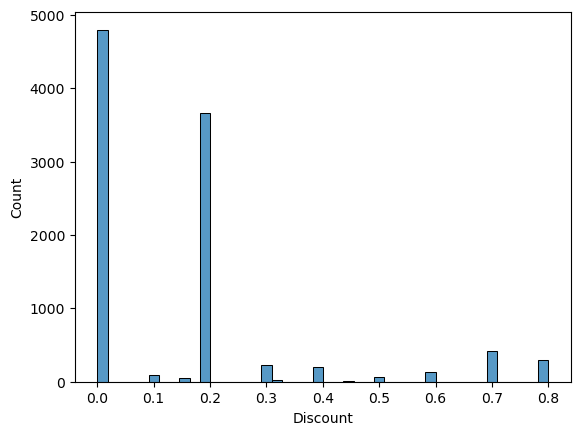

In [54]:
sns.histplot(x=df['Discount'])

<Axes: xlabel='Discount', ylabel='Density'>

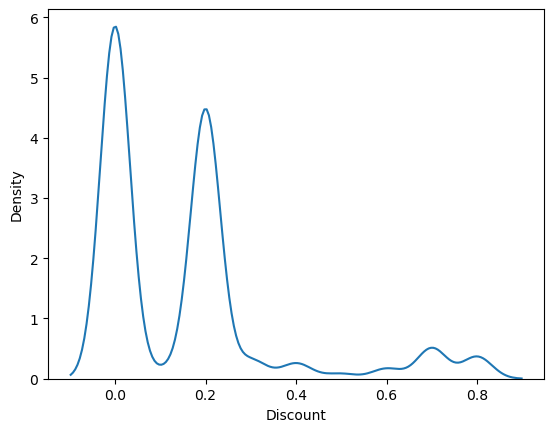

In [55]:
sns.kdeplot(x=df['Discount'])

In [56]:
df['Discount'].kurt()

np.float64(2.4095461225966774)

the average discount is 15%, with the highest discount being 80% and the median discount 20%. we can notice from here the median is greater than the mean which goes to show that the discount is negatively skewed. but the skew went on to show that this is positively skewed. 

though, checking again with the visuals, i could see that this column is multimodal and discrete hence the confusion in the distributions and spread of the values. it would be greate for bivariate analysis

#### next is region


In [57]:
df['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [58]:
df['Region'].describe(include=['O'])

count     9994
unique       4
top       West
freq      3203
Name: Region, dtype: object

In [59]:
prop=df['Region'].value_counts(normalize=True)*100
prop

Region
West       32.049230
East       28.497098
Central    23.243946
South      16.209726
Name: proportion, dtype: float64

In [60]:
cum_pct=(df['Region'].value_counts(normalize=True)).cumsum() * 100
cum_pct

Region
West        32.049230
East        60.546328
Central     83.790274
South      100.000000
Name: proportion, dtype: float64

<Axes: xlabel='Region', ylabel='count'>

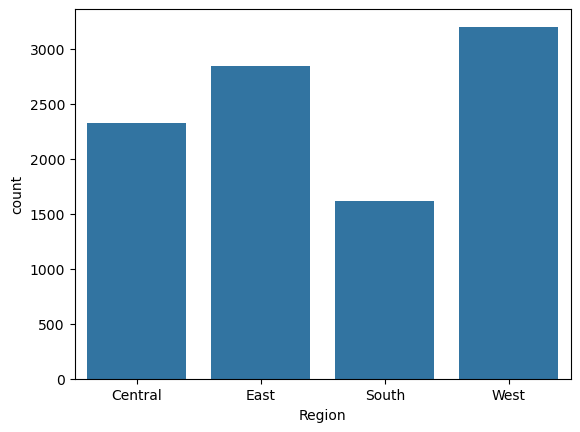

In [61]:
sns.countplot(x=df['Region'])

from what's observed above, region is fairly balanced variable. the west region lead with volume of 32%, the south region comes last with 16.2% of the volume. 
I checked for cardinality and it's only 4 categories and there is no data integrity issue. 

the pareto table check showed that three categories(West, East and Central) make up to more than the 80% of activity or volume. whether these columns have actual contribute to profit or loss, I will find out in Bivariate analysis.


## NEXT - Ship Mode

In [62]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [63]:
perc_prop=df['Ship Mode'].value_counts(normalize=True) * 100
perc_prop

Ship Mode
Standard Class    59.715829
Second Class      19.461677
First Class       15.389234
Same Day           5.433260
Name: proportion, dtype: float64

<Axes: xlabel='count', ylabel='Ship Mode'>

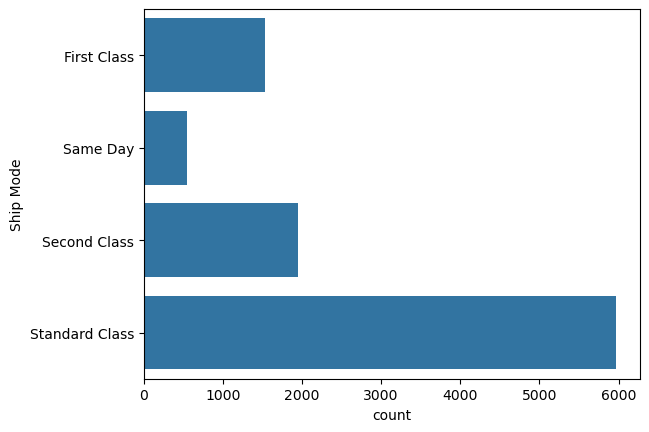

In [64]:
sns.countplot(df['Ship Mode'])

**there is significant IMbalance in ship modes**

([<matplotlib.patches.Wedge at 0x1af2c7ed550>,
 [Text(-0.33056562662942174, 1.0491550726613763, 'Standard class'),
  Text(-0.3760776532491148, -1.0337144667298794, 'second class'),
  Text(0.7465350845565396, -0.8078894525404824, 'First class'),
  Text(1.0840144194562968, -0.18684950738716935, 'same day')])

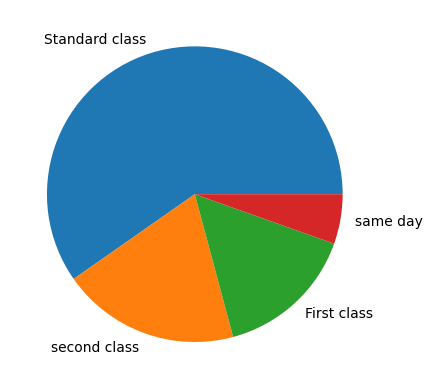

In [65]:
plt.pie(x=perc_prop, labels=['Standard class', 'second class','First class' ,'same day' ])

In [66]:
## pareto check
pareto_ship=df['Ship Mode'].value_counts(normalize=True).cumsum() * 100
pareto_ship

Ship Mode
Standard Class     59.715829
Second Class       79.177507
First Class        94.566740
Same Day          100.000000
Name: proportion, dtype: float64

In [67]:
perc_prop

Ship Mode
Standard Class    59.715829
Second Class      19.461677
First Class       15.389234
Same Day           5.433260
Name: proportion, dtype: float64

in ``Ship Mode`` the `Standard Class` leads the transaction volume with ~ 60% as most used ship mode. `Second Class` and `First Class` follow with 19.5% and 15.4%. the `Same Day` shipping doesnt have much contribution with 5%.  this shows us there is significant amount of imbalance in shipping choices. 

### summary
<!-- - the most popular is - Standard class shipping

- the vital few - most used is standard class shipping and second class shipping amounting to 79% of the transaction, the first class contributes few to make it to pareto (80/20) but its still just 15% contribution from first class.

- are we reliant on few items - we are mostly reliant on standard shipping coz thats what the numbers point.

- near-zero variance - same day shipping has 5% contribution. which is extremely low -->





Shipping mode distribution is heavily concentrated in Standard Class (~60%), followed by Second Class (~19.5%) and First Class (~15.4%). Same Day accounts for only ~5% of transactions.

The concentration suggests that the majority of customers either prefer or default to cost-efficient shipping options. Operational performance improvements in Standard and Second Class will impact ~80% of total order volume.

However, low Same Day usage does not necessarily imply underperformance. Further analysis is required to evaluate profitability, average order value, and customer retention by ship mode before assessing whether this premium tier is underutilized or strategically justified.

``` # Calculate the average profit for each specific discount level you found
failure_analysis = df.groupby('Discount')['Profit'].mean().to_frame()

Add the 'Loss Rate' for each level
failure_analysis['Loss_Rate'] = df.groupby('Discount')['Profit'].apply(lambda x: (x < 0).mean() * 100)

print(failure_analysis)```

### next - segment

In [68]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [69]:
segment_perc=df['Segment'].value_counts(normalize=True) * 100
segment_perc

Segment
Consumer       51.941165
Corporate      30.218131
Home Office    17.840704
Name: proportion, dtype: float64

In [70]:
segment_pareto=df['Segment'].value_counts(normalize=True).cumsum() * 100
segment_pareto

Segment
Consumer        51.941165
Corporate       82.159296
Home Office    100.000000
Name: proportion, dtype: float64

<Axes: xlabel='Segment', ylabel='count'>

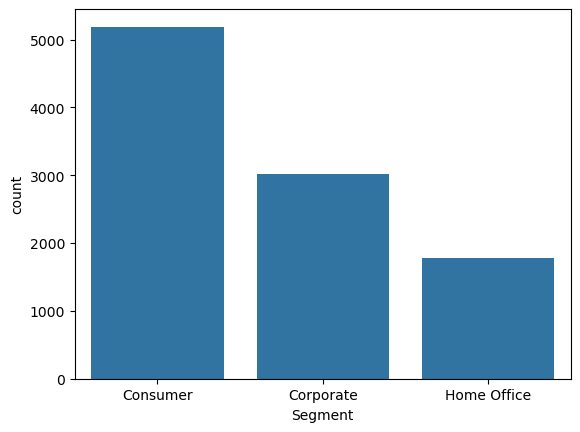

In [71]:
sns.countplot(x=df['Segment'])

Consumer accounts for a majority share (52%) of transactions, followed by Corporate (30%) and Home Office (17%)
This insights suggests that majority of the segments are Consumers, However Operational improvements in processes affecting Consumer and Corporate segments will influence approximately 82% of total transaction volume.
when it comes to Home office segment(~17%), it's low volume segment compared to the other two, but it require further analysis to deem it bad or to pursue opportunities within this segment


###### Volume × improvement = business impact.

## next - subcategory

In [72]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [73]:
sub_prop=df['Sub-Category'].value_counts(normalize=True) * 100
sub_prop

Sub-Category
Binders        15.239143
Paper          13.708225
Furnishings     9.575745
Phones          8.895337
Storage         8.465079
Art             7.964779
Accessories     7.754653
Chairs          6.173704
Appliances      4.662798
Labels          3.642185
Tables          3.191915
Envelopes       2.541525
Bookcases       2.281369
Fasteners       2.171303
Supplies        1.901141
Machines        1.150690
Copiers         0.680408
Name: proportion, dtype: float64

In [74]:
sub_pareto=df['Sub-Category'].value_counts(normalize=True).cumsum() * 100
sub_pareto

Sub-Category
Binders         15.239143
Paper           28.947368
Furnishings     38.523114
Phones          47.418451
Storage         55.883530
Art             63.848309
Accessories     71.602962
Chairs          77.776666
Appliances      82.439464
Labels          86.081649
Tables          89.273564
Envelopes       91.815089
Bookcases       94.096458
Fasteners       96.267761
Supplies        98.168901
Machines        99.319592
Copiers        100.000000
Name: proportion, dtype: float64

<Axes: xlabel='count', ylabel='Sub-Category'>

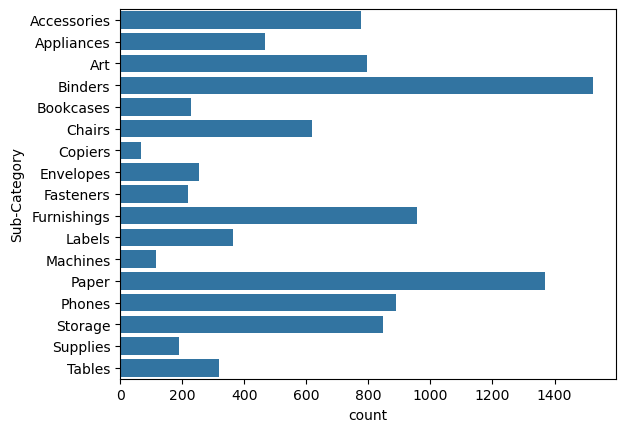

In [75]:
sns.countplot(y=df['Sub-Category'], )

In [76]:
sub_prop

Sub-Category
Binders        15.239143
Paper          13.708225
Furnishings     9.575745
Phones          8.895337
Storage         8.465079
Art             7.964779
Accessories     7.754653
Chairs          6.173704
Appliances      4.662798
Labels          3.642185
Tables          3.191915
Envelopes       2.541525
Bookcases       2.281369
Fasteners       2.171303
Supplies        1.901141
Machines        1.150690
Copiers         0.680408
Name: proportion, dtype: float64

The subcategory is diversly distributed with Binders(~15.2%) taking the lead followed by Paper(13.7%), the rests of subcategories like Furnishings, Phoes, Storage, Arts, Accessories taking up their own shares around (~9% - ~7%) each, with Copiers being the low volume subcategory (~0.69 %).

These sub-categories `Binders`, `Paper`, `Furnishings`, `Phones`, ``Storage``, `Art`, `Accessories`, `Chairs`, `Appliances` cumulatively amount to ~82% of the transaction volume, operational efficiency in managing these different types of sub categories migh taffect the volume of transaction.


Sub-category distribution exhibits moderate concentration, with Binders (15.2%) and Paper (13.7%) leading transaction volume. The top nine subcategories collectively account for approximately 82% of total transactions, indicating that the majority of order flow is concentrated within a core product group.

The remaining subcategories form a long-tail structure, contributing smaller individual shares but potentially increasing operational complexity due to inventory diversification and supply coordination requirements.



# end of univariate

# start of Bivariate

### Bivariate Analysis - Category vs Profit margin

**creating a Profit Margin feature**

In [77]:
df['Profit Margin']=df['Profit'] / df['Sales'] * 100

In [78]:
category_analysis = df.groupby('Category', observed=True).agg(
    Avg_Margin=('Profit Margin', 'mean'),
    Loss_percentage=('Profit', lambda x: (x < 0).mean() * 100),
    total_profit=('Profit', 'sum')
    
).sort_values(by='Avg_Margin', ascending=False)

print(category_analysis)

                 Avg_Margin  Loss_percentage  total_profit
Category                                                  
Technology        15.613805        14.672442   145454.9481
Office Supplies   13.803029        14.702954   122490.8008
Furniture          3.878353        33.663366    18451.2728


In [79]:
# sns.set_context("notebook", font_scale=1.2)

Text(0, 0.5, 'Profit Margin %')

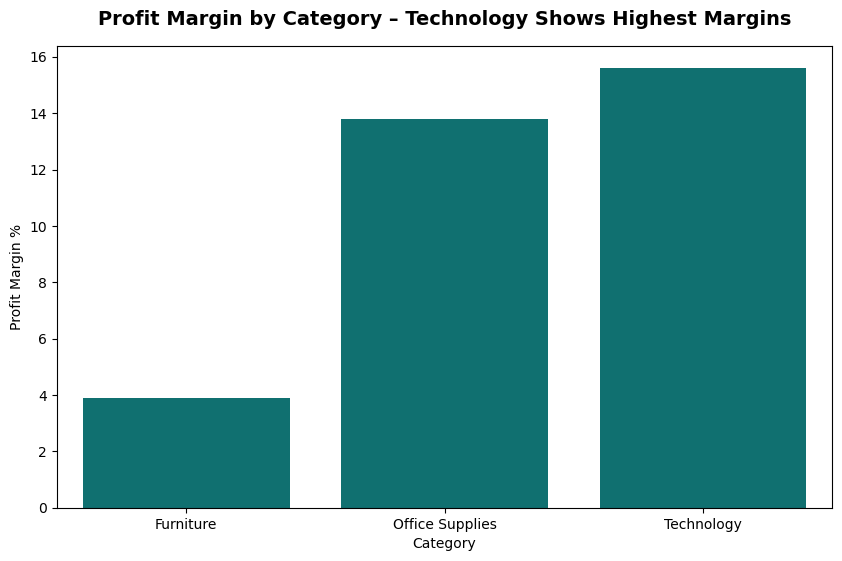

In [80]:
plt.figure(figsize=(10, 6))   
sns.barplot(x=df['Category'], y=df['Profit Margin'], color="teal", errorbar=None)
plt.title("Profit Margin by Category – Technology Shows Highest Margins", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category')
plt.ylabel('Profit Margin %')


Analysing Profit/Profit Margin by Category, we can see that how each of the categories contribute to the following metrics

1. `Avg_Margin` Average margin - this metrics gives insight to which one most profitable per transaction. from the above Analysis, `Technology` which covers ~18.5% of the volume of the transaction is actually the most profitable by far with 15.6% average profit margin. while `Office Supplies`, which has the lead volume coverage of 60%, is moderatly profitable category with average margin of 13.8%, with furniture having the smallest Average margin (3%). 

2. `Loss_percentage` The rate of loss (Negative Profit) - `Furniture` category having loss percentage of ~33.7% makes it more risky category. `Technology` and `Office Supplies` have relatively same amount of risk (~14.7% each).

3. `total_profit` Absolute contribution to Profit - `Technology` has high contribution to profit (**$145454**), `Office Supplies` comes close (**$122490**). Furniture has the lowest contribution to profit (**$18451**).


From the Insights, Its observed that `Technology` is the most profitable, low-loss risk and high overall contributing category. Meanwhile, `Furniture` is dragging down the profitability of the superstore by having low average profit margin, high-loss risk and low contribution to the overall profit. The margins are collapsing in `Furniture` Category. the financial impacts for the superstore are positively high towards `Technology` and Negatively high in `Furniture` category.

**Recommendations**
* Perform a Product Portfolio Rationalization. Furniture is currently consuming a disproportionate amount of 'Operational Gravity' (warehouse space and labor) for minimal profit return.

* The analysis shows that `Technology` is our most capital-efficient segment, yielding the highest profit despite representing the lowest physical volume. To maximize ROI, we should reallocate working capital from high-volume/loss-making categories (like Furniture) into `Technology`.



In [81]:
region_analysis = df.groupby('Region', observed=True).agg(
    Avg_Margin=('Profit Margin', 'mean'),
    Loss_percentage=('Profit', lambda x: (x < 0).mean() * 100),
    total_profit=('Profit', 'sum')
    
).sort_values(by='Avg_Margin', ascending=False)

print(region_analysis)

         Avg_Margin  Loss_percentage  total_profit
Region                                            
West      21.948662         9.928192   108418.4489
East      16.722696        19.417135    91522.7800
South     16.351903        15.987654    46749.4303
Central  -10.407294        31.898407    39706.3625


In [82]:
df.groupby('Region')['Discount'].mean()

C:\Users\Hello\AppData\Local\Temp\ipykernel_10640\3213994647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Region')['Discount'].mean()


Region
Central    0.240353
East       0.145365
South      0.147253
West       0.109335
Name: Discount, dtype: float64

In [83]:
region_analysis

,Avg_Margin,Loss_percentage,total_profit
Region,,,
West,21.948662,9.928192,108418.4489
East,16.722696,19.417135,91522.7800
South,16.351903,15.987654,46749.4303
Central,-10.407294,31.898407,39706.3625


(0.0, 23.56645957978939)

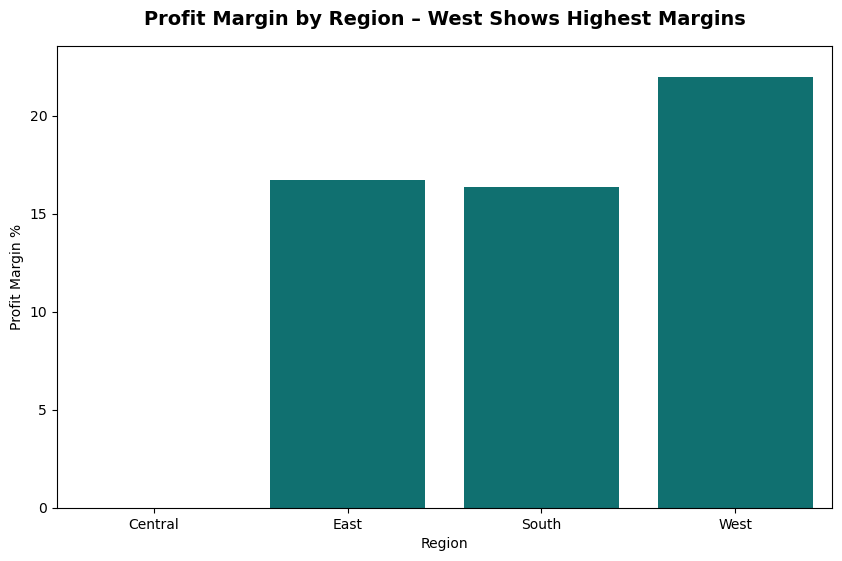

In [84]:
plt.figure(figsize=(10, 6))   
sns.barplot(x=df['Region'], y=df['Profit Margin'], color="teal", errorbar=None)
plt.title("Profit Margin by Region – West Shows Highest Margins", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region')
plt.ylabel('Profit Margin %')
plt.ylim(bottom=0)


Analysis of Profit/Profit Margin by `Region`. we can see that how each of the categories contribute to the following metrics

1. `Avg_Margin` Average Profit margin - this metrics gives insight to which `Region` most profitable per transaction. from the above Analysis, `West` which covers ~32% of the volume of the transaction is the most profitable by far with 21.9% average profit margin. while `East`, which has volume coverage of 28%, is moderatly profitable category with average margin of 16.7%. The `South` Region follows with average margin of 16.3%, with `Central` having the Negative Average margin (-10.4%). 

2. `Loss_percentage` The rate of loss (Negative Profit) - `Central` Region having loss percentage of ~31.9% makes it more risky Region. `East` and `South` have respectively ~19.4% and ~16% of risk. The `West` region have the lowest loss rate(~9.9%).

3. `total_profit` Absolute contribution to Profit - `West` Region has high contribution to profit (**$108418**), `East` and `South` comes Second and Third(**$91522**) and (**$46749**) respectively. `Central` Region has the lowest contribution to profit (**$39706**).

From the Insights, Its observed that `West` is the most profitable, low-loss-risk and high-performing Region. Meanwhile, `Central` is dragging down the profitability of the superstore by having Negative average profit margin, high-loss risk and low performace. The margins are extremly collapsing in `Central` Category. the financial impacts for the superstore are positively high towards `West` and Negatively high in `Central` Region.

**Recommendations**

1. Conduct a Best-Practice Audit of the `West` Region. This region should serve as the organizational benchmark for 'Commercial Excellence.'

2. Given the high 'Return on Sales' and low loss rate, every dollar of customer acquisition spend in this territory yields a significantly higher net profit compared to other regions.

3. The Central Region is currently operating at a negative net margin, acting as a primary drain on total Superstore profitability. I recommend an immediate Regional Pricing Audit.


In [85]:
df.groupby('Region')['Discount'].mean()

C:\Users\Hello\AppData\Local\Temp\ipykernel_10640\3213994647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Region')['Discount'].mean()


Region
Central    0.240353
East       0.145365
South      0.147253
West       0.109335
Name: Discount, dtype: float64

In [86]:
segment_analysis = df.groupby('Segment', observed=True).agg(
    Avg_Margin=('Profit Margin', 'mean'),
    Loss_percentage=('Profit', lambda x: (x < 0).mean() * 100),
    total_profit=('Profit', 'sum')
    
).sort_values(by='Avg_Margin', ascending=False)

print(segment_analysis)

             Avg_Margin  Loss_percentage  total_profit
Segment                                               
Home Office   14.286959        17.498598    60298.6785
Corporate     12.120261        18.410596    91979.1340
Consumer      11.204952        19.321903   134119.2092


(0.0, 15.00130643140854)

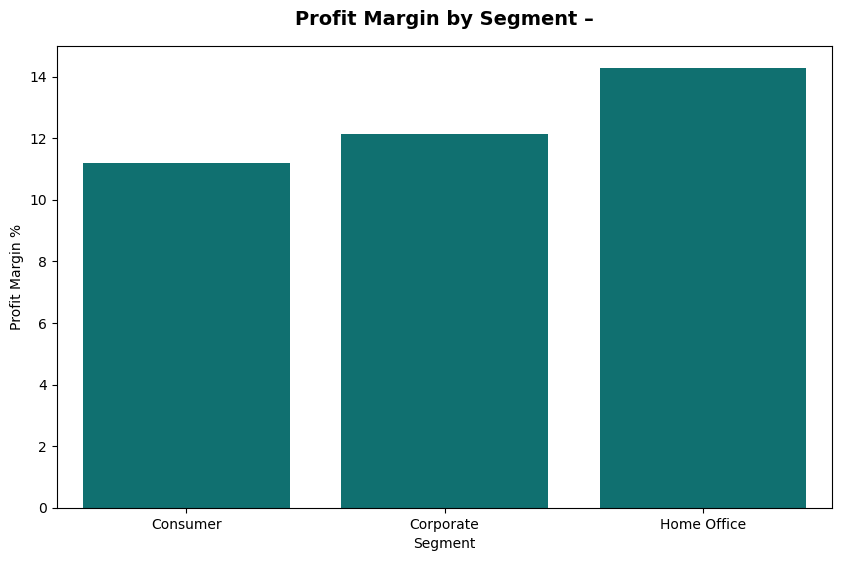

In [87]:
plt.figure(figsize=(10, 6))   
sns.barplot(x=df['Segment'], y=df['Profit Margin'], color="teal", errorbar=None)
plt.title("Profit Margin by Segment –", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Segment')
plt.ylabel('Profit Margin %')
plt.ylim(bottom=0)

Analysing Profit/Profit Margin by `Segment`, we can see that how each of the Segments contribute to the following metrics

1. `Avg_Margin` Average margin - this metric gives insight to which Segment most profitable per transaction. from the above Analysis, `Home Office` which covers ~17.8% of the volume of the transaction is actually the most profitable by far with 14.29% average profit margin. while `Corporate`, which has the lead volume coverage of 30%, is moderately profitable category with average margin of ~12%, with Consumer having the Lowest Average margin (11%). 

2. `Loss_percentage` The rate of loss (Negative Profit %) - `Consumer` Segment having loss percentage of ~19.3% makes it more risky Segment. `Corporate` and `Home Office` have relatively same amount of risk (~18% and ~17% respectively).

3. `total_profit` Absolute contribution to Profit - `Consumer` has high contribution to profit (**$134119**), `Corporate` comes close (**$91979**). `Home Office` has the lowest contribution to profit (**$60298**).


From the Insights, The Consumer segment contributes the largest share of total profit ($134k) due to high transaction volume, but it shows the lowest average margin (11.2%) and highest proportion of loss-making orders (19.3%). Home Office delivers the strongest per-order economics (14.3% margin, only 17.5% losses) despite lower volume.

**Recommendations**
* protect/grow `Consumer` volume while reducing loss rate,

* `Home Office` is a high-quality segment — consider targeted marketing / upselling here to increase share



### ship mode vs profit/profit margin

In [88]:
ship_analysis = df.groupby('Ship Mode', observed=True).agg(
    Avg_Margin=('Profit Margin', 'mean'),
    Loss_percentage=('Profit', lambda x: (x < 0).mean() * 100),
    total_profit=('Profit', 'sum')
    
).sort_values(by='Avg_Margin', ascending=False)

print(ship_analysis)

                Avg_Margin  Loss_percentage  total_profit
Ship Mode                                                
Second Class     15.020878        15.784062    57446.6354
Same Day         13.815135        18.047882    15891.7589
First Class      11.594781        19.050715    48969.8399
Standard Class   11.007329        19.654826   164088.7875


(0.0, 15.771922200990705)

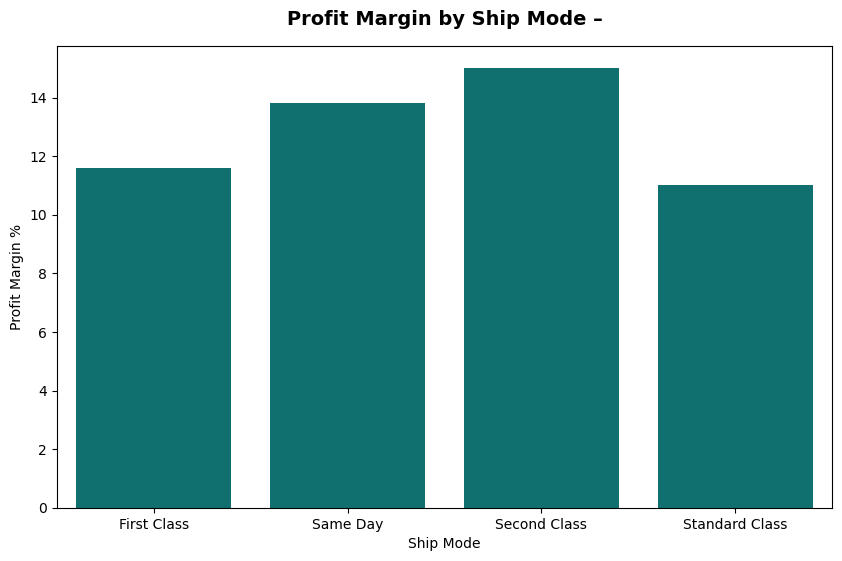

In [89]:
plt.figure(figsize=(10, 6))   
sns.barplot(x=df['Ship Mode'], y=df['Profit Margin'], color="teal", errorbar=None)
plt.title("Profit Margin by Ship Mode –", fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ship Mode')
plt.ylabel('Profit Margin %')
plt.ylim(bottom=0)


While profitability metrics across `Ship Mode`s show moderate variance, no material performance risk is observed. `Standard Class` drives the majority of total profit due to volume dominance despite having the lowest average margin (11%). `Second Class` demonstrates the strongest per-transaction profitability (15% Avg Margin). No immediate strategic intervention is required; however, minor margin optimization opportunities may exist within `Standard Class`.


<Axes: xlabel='Discount', ylabel='Profit'>

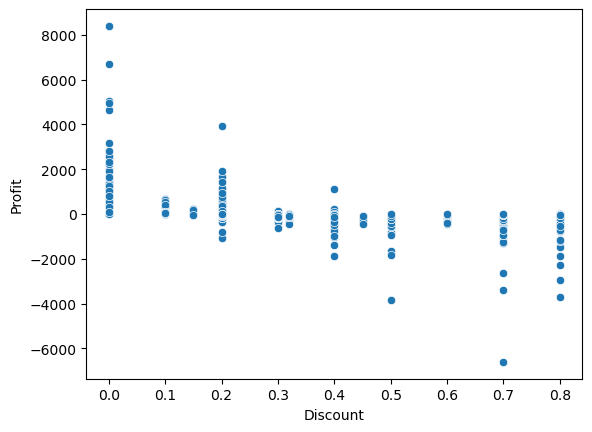

In [90]:
plt.Figure(figsize=(10,6))
sns.scatterplot(data=df, y='Profit', x='Discount')


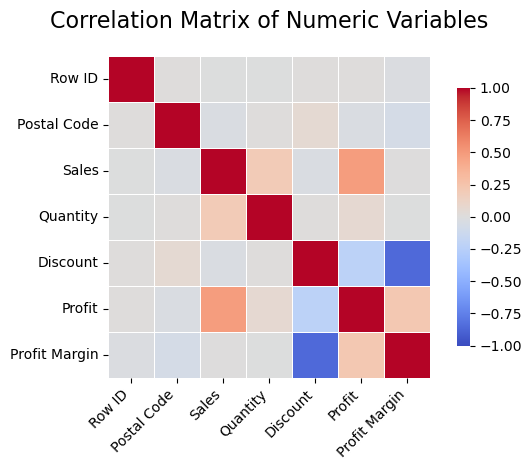

In [91]:
sns.heatmap(df.corr(numeric_only=True), annot=False, fmt=".1f",                # 2 decimal places
    cmap="coolwarm",          # diverging colormap: red positive, blue negative
    # alternative good colormaps: "RdBu_r", "viridis", "mako", "vlag"
    vmin=-1, vmax=1,          # fix scale to full correlation range
    center=0,                 # center at zero for diverging
                # hide upper triangle (symmetric)
    linewidths=0.5,           # thin lines between cells
    cbar_kws={"shrink": 0.8}, # smaller colorbar
    square=True)
plt.title("Correlation Matrix of Numeric Variables", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# 7. Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Show the plot
plt.show()

<Axes: xlabel='Sales', ylabel='Profit'>

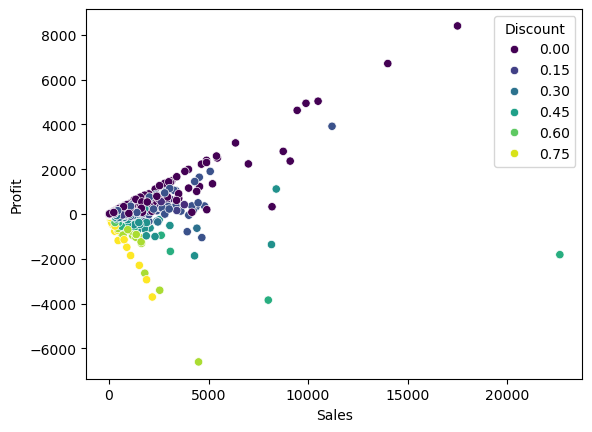

In [92]:
plt.Figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Discount', palette='viridis')

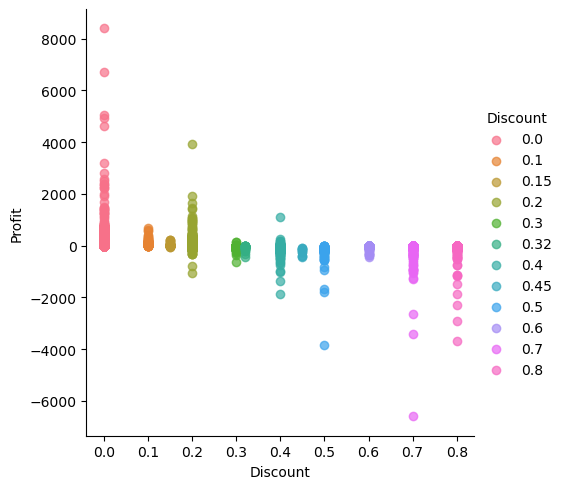

In [93]:
sns.lmplot(data=df, x='Discount', y='Profit', hue='Discount', 
         scatter_kws={'alpha':0.7})

### Bivariate Summary – Key Drivers of Profitability

- Region: West is the clear outperformer (highest margin, lowest loss rate, highest total profit contribution). Central is the biggest drag (negative avg margin, 31.9% loss rate).
- Segment: Home Office shows strongest margins and efficiency; Consumer dominates volume but lower per-order profitability.
- Discount: Strong negative relationship — higher discounts correlate with negative profit (visible in scatter).
- Category: Office Supplies dominates volume but Technology likely drives disproportionate profit (to be confirmed in multivariate).

These factors explain most of the variation in negative vs high-margin outcomes. Next: multivariate interactions to confirm which combinations are most damaging.

## MultiVariate Analysis


####  I am gonna start with Profit by Region and Category

In [94]:
df.groupby(['Region', 'Category'])['Profit'].mean()

C:\Users\Hello\AppData\Local\Temp\ipykernel_10640\3549060166.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Region', 'Category'])['Profit'].mean()


Region   Category       
Central  Furniture          -5.968918
         Office Supplies     6.244712
         Technology         80.231981
East     Furniture           5.068496
         Office Supplies    23.957114
         Technology         88.714084
South    Furniture          20.395199
         Office Supplies    20.086827
         Technology         68.231506
West     Furniture          16.272914
         Office Supplies    27.733183
         Technology         73.962687
Name: Profit, dtype: float64

In [95]:
RegCat_analysis = df.groupby(['Region', "Category"], observed=True).agg(
    Avg_Order_Value=('Sales', 'mean'),
    Avg_Profit_margin_per_Order=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean'),
    Transaction_Count=('Sales', 'count'),
    Total_prof=('Profit', 'sum'),
    avg_profit_per_ordr=('Profit', 'mean'),
    total_profit_margin=('Profit Margin', 'sum')).reset_index()
RegCat_analysis

,Region,Category,Avg_Order_Value,Avg_Profit_margin_per_Order,Avg_Discount,Transaction_Count,Total_prof,avg_profit_per_ordr,total_profit_margin
0,Central,Furniture,340.534644,-18.583641,0.297380,481,-2871.0494,-5.968918,-8938.731092
1,Central,Office Supplies,117.458801,-15.887912,0.252743,1422,8879.9799,6.244712,-22592.611111
2,Central,Technology,405.753124,17.512377,0.133095,420,33697.4320,80.231981,7355.198413
3,East,Furniture,346.574383,9.238888,0.154077,601,3046.1658,5.068496,5552.571429
4,East,Office Supplies,120.044425,20.630549,0.142932,1712,41014.5791,23.957114,35319.500000
5,East,Technology,495.278469,12.624611,0.143364,535,47462.0351,88.714084,6754.166667
6,South,Furniture,353.309289,14.166165,0.121536,332,6771.2061,20.395199,4703.166667
7,South,Office Supplies,126.282727,16.316499,0.167437,995,19986.3928,20.086827,16234.916667
8,South,Technology,507.753952,18.948805,0.107850,293,19991.8314,68.231506,5552.000000
9,West,Furniture,357.302325,9.772249,0.131400,707,11504.9503,16.272914,6908.980392


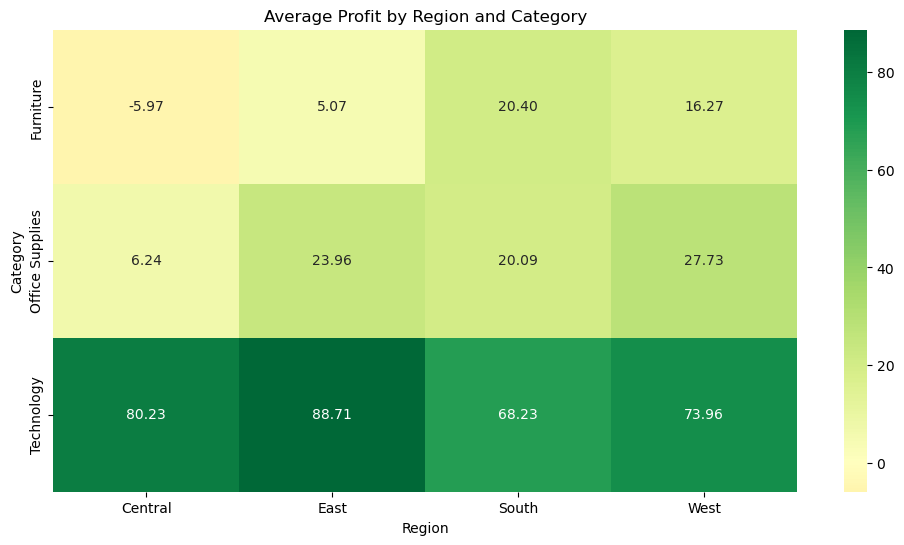

In [96]:

pivot_table = df.pivot_table(index='Category', columns='Region', values='Profit', aggfunc='mean', observed=True)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title("Average Profit by Region and Category")
plt.show()

In the Central region, profitability is driven more by margin strength than volume: Technology delivers the highest per-order profit (~$80) and ~$33k total contribution despite lowest transactions, while Furniture incurs ~6% average losses due to higher discounting — despite its higher AOV.

### Profit by Region – Category Performance Highlight

#### Central
* Technology is the most profitable category in Central despite the lowest transaction volume: ~$80 average profit per order and ~$33k total profit contribution.
* Furniture incurs ~$5 average losses despite higher AOV(Average Order Value), driven by elevated average discounts.
→ Opportunity: Reduce discounting in Furniture to stem losses; selectively grow Technology share to boost regional profitability.

#### East
* Technology is the most profitable category in the East despite the lowest transaction volume: ~$89 average profit per order and ~$48k total profit contribution.
* Furniture turns in ~$6 average profit despite higher AOV(~$347), driven by elevated average discounts.

#### South
* Technology is the most profitable category in South despite the lowest transaction volume: ~$68 average profit per order and ~$20k total profit contribution.
* Furniture turns in ~$20.4 average profit per order despite having medium transaction volume and moderate discounting. 

#### West
* Technology is the most profitable category in West despite the lowest transaction volume: ~$73 average profit per order and ~$44k total profit contribution.
* Office Supplies turns in the most amount of total profit in West despite having moderate ($27) of average profit per order. it also has the highes transaction volume and low discounting.
* Furniture turns in ~$17 average profit per order despite having medium transaction volume and moderate discounting. 


#### Overall Insights
* in all regions, Technology is consistently showing high profit margin and high average profit per order despite the low transaction volume. 
* Office Supplies is High-Volume, High-Total-Profit category in all regions, even though the Average is not as high as the total profit it brings in
* Furniture in all regions is consistently having low contribution to total profit and high discounts.

### Profit by Region – Category Performance Summary

**Technology** consistently delivers the **highest average profit per order** across all regions despite having the **lowest transaction volume** in each:
- Central: ~$80/order, ~$33k total contribution
- East: ~$89/order, ~$48k total
- South: ~$68/order, ~$20k total
- West: ~$73/order, ~$44k total

**Furniture** is the weakest performer in most regions:
- Central: ~$5 average loss per order (driven by high discounts)
- East: ~$6 average profit (still low relative to high AOV ~$347)
- South & West: modest positive profit (~$20 and ~$17/order) but low overall contribution

**Office Supplies** stands out in the **West** as the **top total-profit contributor** due to highest transaction volume and low discounting, even though per-order profit is moderate (~$27).

**Cross-Region Takeaway**  
Profitability is driven more by **per-order margin strength** (Technology) than sheer volume in most regions. Furniture consistently underperforms due to higher discounting, while Office Supplies provides stable volume-driven profit (especially West).  

**Opportunities**  
- Tighten discount controls in Furniture (especially Central) to eliminate losses.  
- Invest in growing Technology share across all regions to leverage its superior economics.

### Profit by Segment-Category

In [97]:
profit_pivot = df.pivot_table(
    values='Profit',
    index='Segment',
    columns='Category',
    aggfunc=['mean', 'sum', 'count'], observed=True
).round(2)
profit_pivot

mean                                  sum                  \
Category    Furniture Office Supplies Technology Furniture Office Supplies   
Segment                                                                      
Consumer         6.28           18.01      74.45   6991.08        56330.32   
Corporate       11.74           22.10      79.72   7584.82        40227.32   
Home Office     10.71           24.03      89.15   3875.38        25933.16   

                           count                             
Category    Technology Furniture Office Supplies Technology  
Segment                                                      
Consumer      70797.81      1113            3127        951  
Corporate     44167.00       646            1820        554  
Home Office   30490.14       362            1079        342

In [98]:
df.groupby(['Segment', 'Category'], observed=True)['Profit'].mean()

Segment      Category       
Consumer     Furniture           6.281293
             Office Supplies    18.014174
             Technology         74.445646
Corporate    Furniture          11.741201
             Office Supplies    22.102923
             Technology         79.723823
Home Office  Furniture          10.705465
             Office Supplies    24.034439
             Technology         89.152458
Name: Profit, dtype: float64

In [99]:
# Slicing the data for your high-performing segment
niche_analysis = df.groupby(['Segment', 'Category'], observed=True).agg(
    Avg_Order_Value=('Sales', 'mean'),
    Avg_Profit_margin_per_Order=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean'),
    Transaction_Count=('Sales', 'count'),
    Total_prof=('Profit', 'sum'),
    avg_profit_per_ordr=('Profit', 'mean')
).reset_index()

# Calculate 'Profitability Efficiency' (How much profit we get per $100 of sales)
niche_analysis['Profit_per_100_Sales'] = (niche_analysis['Avg_Profit_margin_per_Order'] / niche_analysis['Avg_Order_Value']) * 100

print(niche_analysis.sort_values(by='Avg_Profit_margin_per_Order', ascending=False))

       Segment         Category  Avg_Order_Value  Avg_Profit_margin_per_Order  \
8  Home Office       Technology       535.976658                    16.688805   
7  Home Office  Office Supplies       115.309021                    16.570590   
5    Corporate       Technology       444.855810                    15.543121   
2     Consumer       Technology       427.339534                    15.268389   
4    Corporate  Office Supplies       126.745309                    13.754930   
1     Consumer  Office Supplies       116.390194                    12.876053   
6  Home Office        Furniture       336.825131                     5.211074   
3    Corporate        Furniture       354.519792                     4.579453   
0     Consumer        Furniture       351.347091                     3.037962   

   Avg_Discount  Transaction_Count  Total_prof  avg_profit_per_ordr  \
8      0.127193                342  30490.1405            89.152458   
7      0.147451               1079  25933.1596 

In [100]:
niche_analysis

,Segment,Category,Avg_Order_Value,Avg_Profit_margin_per_Order,Avg_Discount,Transaction_Count,Total_prof,avg_profit_per_ordr,Profit_per_100_Sales
0,Consumer,Furniture,351.347091,3.037962,0.176739,1113,6991.0786,6.281293,0.864661
1,Consumer,Office Supplies,116.390194,12.876053,0.158746,3127,56330.3210,18.014174,11.062833
2,Consumer,Technology,427.339534,15.268389,0.134385,951,70797.8096,74.445646,3.572894
3,Corporate,Furniture,354.519792,4.579453,0.174071,646,7584.8158,11.741201,1.291734
4,Corporate,Office Supplies,126.745309,13.754930,0.160604,1820,40227.3202,22.102923,10.852417
5,Corporate,Technology,444.855810,15.543121,0.131949,554,44166.9980,79.723823,3.493968
6,Home Office,Furniture,336.825131,5.211074,0.165000,362,3875.3784,10.705465,1.547116
7,Home Office,Office Supplies,115.309021,16.570590,0.147451,1079,25933.1596,24.034439,14.370593
8,Home Office,Technology,535.976658,16.688805,0.127193,342,30490.1405,89.152458,3.113719


<Axes: xlabel='Region', ylabel='Profit'>

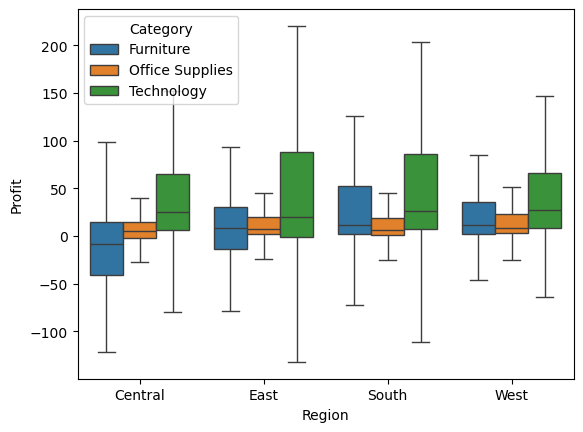

In [101]:
sns.boxplot(data=df, x='Region', y='Profit', hue='Category', showfliers=False)

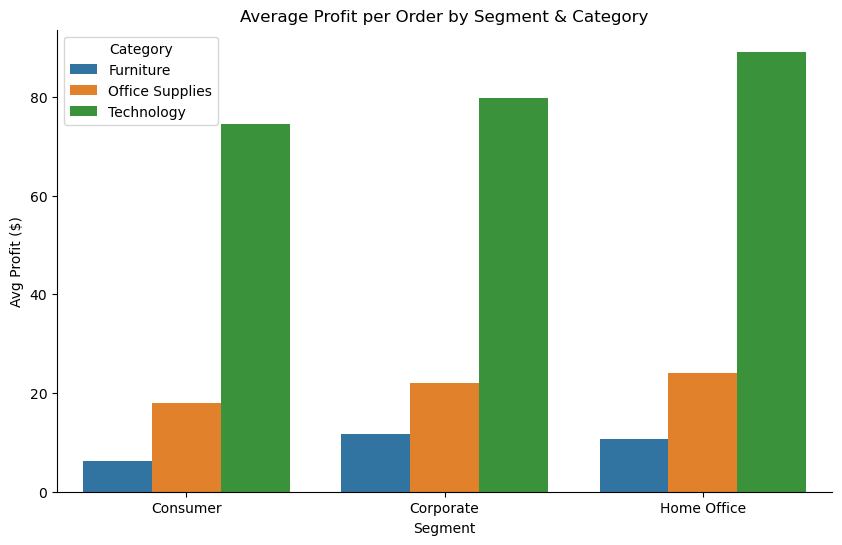

In [102]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='Segment',
    y='Profit',
    hue='Category',
    estimator='mean',   
    errorbar=None
)
plt.title("Average Profit per Order by Segment & Category")
plt.ylabel("Avg Profit ($)")
plt.ylim(bottom=0) 
sns.despine()
plt.show()

In [103]:
niche_analysis

,Segment,Category,Avg_Order_Value,Avg_Profit_margin_per_Order,Avg_Discount,Transaction_Count,Total_prof,avg_profit_per_ordr,Profit_per_100_Sales
0,Consumer,Furniture,351.347091,3.037962,0.176739,1113,6991.0786,6.281293,0.864661
1,Consumer,Office Supplies,116.390194,12.876053,0.158746,3127,56330.3210,18.014174,11.062833
2,Consumer,Technology,427.339534,15.268389,0.134385,951,70797.8096,74.445646,3.572894
3,Corporate,Furniture,354.519792,4.579453,0.174071,646,7584.8158,11.741201,1.291734
4,Corporate,Office Supplies,126.745309,13.754930,0.160604,1820,40227.3202,22.102923,10.852417
5,Corporate,Technology,444.855810,15.543121,0.131949,554,44166.9980,79.723823,3.493968
6,Home Office,Furniture,336.825131,5.211074,0.165000,362,3875.3784,10.705465,1.547116
7,Home Office,Office Supplies,115.309021,16.570590,0.147451,1079,25933.1596,24.034439,14.370593
8,Home Office,Technology,535.976658,16.688805,0.127193,342,30490.1405,89.152458,3.113719


#### Profit by Segment and Category Summary

* Across All Segments, Technology is Highly profitable Despite having low transaction volume and low discounting
* Across all segments, Furniture is poorly performing category with consistent high Dsicounting and low Profit margin per order.
* highest purchases of Technology is made by Home Offices, Highest purchases of Office Supplies and Furnitures are made by Corporates. 


**Cross-Region Takeaway**  
Profitability is driven more by **per-order margin strength** (Technology) than sheer volume in all Segments. Furniture consistently underperforms due to higher discounting, while Office Supplies provides stable volume-driven profit (especially Home Office).  
 

## Profit by Category and Discount

In [124]:

df['discount_bin']=pd.cut(x=df['Discount'], bins=[-0.001, 0.0, 0.2 ,0.3, 0.8], labels=['No Discount','Low', 'Medium', 'High'])

In [123]:
discat=df.groupby(['Category', 'discount_bin'], observed=True)[['Profit', 'Discount']].agg(
    avg_profit_per_category=('Profit', 'mean'),
    avg_discount_per_category=('Discount', 'mean'),
    total_profit_per_category=('Profit', 'sum')
)
discat

avg_profit_per_category  \
Category        discount_bin                            
Furniture       No Discount                 69.537173   
                Low                         19.913799   
                Medium                     -48.177103   
                High                      -136.820122   
Office Supplies No Discount                 41.708567   
                Low                         17.647646   
                High                       -69.323732   
Technology      No Discount                158.881657   
                Low                         55.592752   
                Medium                      65.207900   
                High                      -205.326517   

                              avg_discount_per_category  \
Category        discount_bin                              
Furniture       No Discount                    0.000000   
                Low                            0.186272   
                Medium                         0.300000   
                High                           0.512156   
Office Supplies No Discount                    0.000000   
                Low                            0.199278   
                High                           0.744118   
Technology      No Discount                    0.000000   
                Low                            0.199763   
                Medium                         0.300000   
                High                           0.448795   

                              total_profit_per_category  
Category        discount_bin                             
Furniture       No Discount                  58133.0764  
                Low                          14795.9525  
                Medium                      -10695.3169  
                High                        -43782.4392  
Office Supplies No Discount                 130506.1064  
                Low                          39124.8320  
                High                        -47140.1376  
Technology      No Discount                 132348.4204  
                Low                          46864.6900  
                Medium                         326.0395  
                High                        -34084.2018

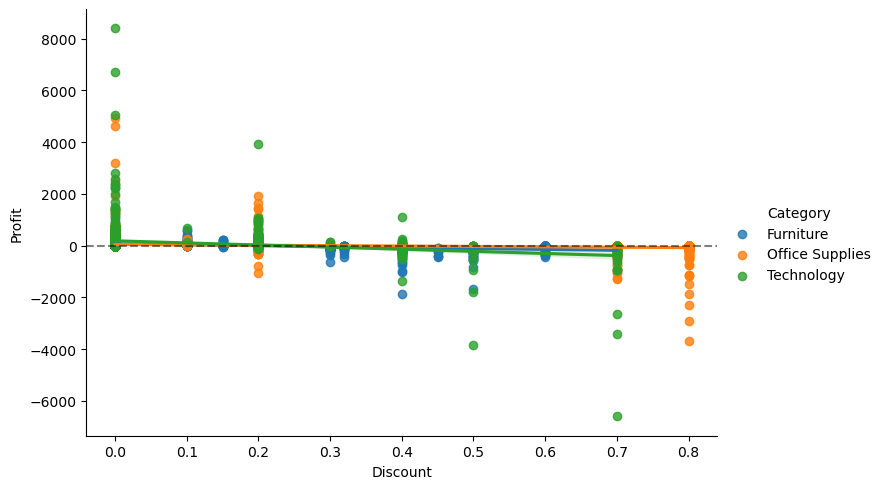

In [106]:
sns.lmplot(data=df, x='Discount', y='Profit', hue='Category', aspect=1.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

### Profit by Category and Discount - Analysis summary
**Discount** is divided across three bins to observe the behavior it has on `Profit`. the threshold is set as 
* **No Discount** - no discount applied.
* **Low** - a discount between `0%` to `20%` inclusively
* **Medium** - a discount above `20%` and `30%` inclusively
* **High** - a discount above `30%`

#### Summary
* Across All categories, High discounting is causing loss to the business. On average, in `Furniture` ~-$136, in `Office Supplies` ~-$69, in `Technology` ~-$205.

#### Recommendation and Insights
* Cut discounting at **Low** level upto 20%. especially in `Technology`
* Before Implementing High Discount, Consult the Finance people


### Profit by Region and Segment


In [107]:
regseg= df.groupby(['Region', 'Segment'], observed=True).agg(
    Avg_sales=('Sales', 'mean'),
    Avg_Profit_margin_per_Region=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean'),
    Transaction_Count=('Sales', 'count'),
    Total_prof=('Profit', 'sum'),
    avg_profit=('Profit', 'mean')
)
regseg

Avg_sales  Avg_Profit_margin_per_Region  Avg_Discount  \
Region  Segment                                                               
Central Consumer     207.946728                    -14.164628      0.252030   
        Corporate    234.763466                     -8.355278      0.239822   
        Home Office  208.248046                     -3.163271      0.208858   
East    Consumer     238.875539                     16.777251      0.147447   
        Corporate    228.516929                     15.407029      0.144356   
        Home Office  253.911805                     18.861538      0.141036   
South   Consumer     233.390180                     16.899355      0.142124   
        Corporate    238.992025                     15.286557      0.157745   
        Home Office  272.996329                     16.662795      0.143382   
West    Consumer     217.033955                     21.845093      0.107506   
        Corporate    235.265911                     21.789772      0.113958   
        Home Office  239.442692                     22.519067      0.106918   

                     Transaction_Count  Total_prof  avg_profit  
Region  Segment                                                 
Central Consumer                  1212   8564.0481    7.066046  
        Corporate                  673  18703.9020   27.791831  
        Home Office                438  12438.4124   28.398202  
East    Consumer                  1469  41190.9843   28.040153  
        Corporate                  877  23622.5789   26.935666  
        Home Office                502  26709.2168   53.205611  
South   Consumer                   838  26913.5728   32.116435  
        Corporate                  510  15215.2232   29.833771  
        Home Office                272   4620.6343   16.987626  
West    Consumer                  1672  57450.6040   34.360409  
        Corporate                  960  34437.4299   35.872323  
        Home Office                571  16530.4150   28.949939

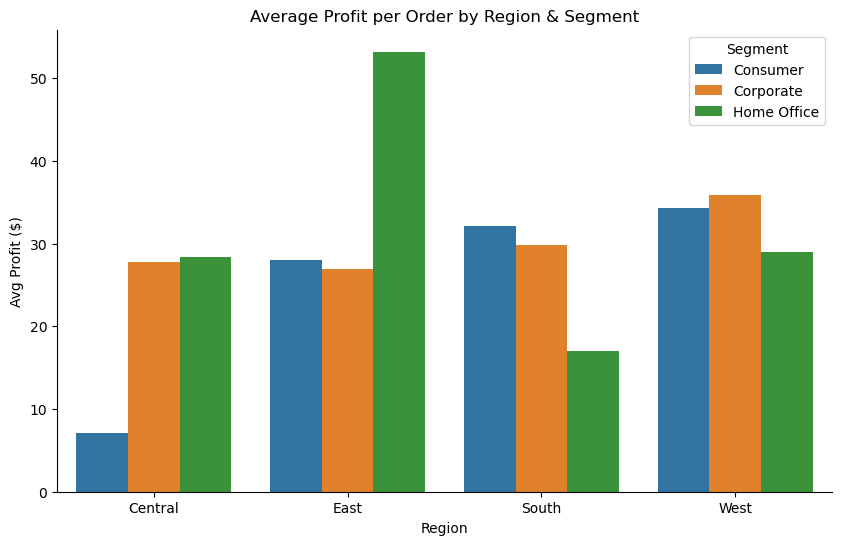

In [108]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='Region',
    y='Profit',
    hue='Segment',
    estimator='mean',   
    errorbar=None
)
plt.title("Average Profit per Order by Region & Segment")
plt.ylabel("Avg Profit ($)")
#plt.ylim(bottom=0) 
sns.despine()
plt.show()

In [109]:
regseg

Avg_sales  Avg_Profit_margin_per_Region  Avg_Discount  \
Region  Segment                                                               
Central Consumer     207.946728                    -14.164628      0.252030   
        Corporate    234.763466                     -8.355278      0.239822   
        Home Office  208.248046                     -3.163271      0.208858   
East    Consumer     238.875539                     16.777251      0.147447   
        Corporate    228.516929                     15.407029      0.144356   
        Home Office  253.911805                     18.861538      0.141036   
South   Consumer     233.390180                     16.899355      0.142124   
        Corporate    238.992025                     15.286557      0.157745   
        Home Office  272.996329                     16.662795      0.143382   
West    Consumer     217.033955                     21.845093      0.107506   
        Corporate    235.265911                     21.789772      0.113958   
        Home Office  239.442692                     22.519067      0.106918   

                     Transaction_Count  Total_prof  avg_profit  
Region  Segment                                                 
Central Consumer                  1212   8564.0481    7.066046  
        Corporate                  673  18703.9020   27.791831  
        Home Office                438  12438.4124   28.398202  
East    Consumer                  1469  41190.9843   28.040153  
        Corporate                  877  23622.5789   26.935666  
        Home Office                502  26709.2168   53.205611  
South   Consumer                   838  26913.5728   32.116435  
        Corporate                  510  15215.2232   29.833771  
        Home Office                272   4620.6343   16.987626  
West    Consumer                  1672  57450.6040   34.360409  
        Corporate                  960  34437.4299   35.872323  
        Home Office                571  16530.4150   28.949939

### Profit by Region – Segment Performance Highlight

#### Central
* Home Office is the most profitable Segment on Average profit in Central despite the lowest transaction volume: ~$28 average profit per order with average discount of 20%. However, when it comes to total profit contribution it has ~$12k total profit contribution which is less than `Corporate` segment that brings ~$19k total profit and ~$27 on average profit with average ~24% discounting.
* `Consumer` brings in the lower profit in both average and total, ~$7 average profit despite higher AOV(Average Order Value) and ~8.5k total profit contribution, driven by elevated average discounts(~25%).
→ Opportunity: Reduce discounting in Consumer segment to stem losses; selectively grow Technology share to boost regional profitability.

#### East
* `Home Office` is a profitable Segment in the East despite the lowest transaction volume: ~$53 average profit per order and ~$26k total profit contribution with ~14% average discounts. `Corporate` is performing moderately with ~$26 average profit and ~$23k total profit contribution with ~14% average discounts.
* `Consumer` turns in ~$28 average profit despite higher AOV(~$238), highest total contribution(~$42k) and highest transaction volume with ~15% average discounts.

#### South
* `Consumer` is the most profitable Segment in South with the highest transaction volume: ~$32 average profit per order and ~$27k total profit contribution with ~14% average discounts.
* `Corporate` turns in ~$30 average profit per order having medium transaction volume and with ~16% average discounting. `Home Office` turns in the lowest profit with ~$16 average profit and total contribution of ~$4.7k with ~14% average discounts

#### West
* `Corporate` is the most profitable Segment in West despite the medium transaction volume: ~$35 average profit per order and ~$34k total profit contribution.
* `Consumer` turns in the most amount of total profit(~$57k) in West despite having moderate ($34) of average profit per order. it also has the highest transaction volume and low discounting(~11% average discounts).
* `Home Office` turns in ~$28 average profit per order and total profit of ~$16.5k despite having low transaction volume and high AOV. 


#### Overall Insights
* `Consumer` is High-Volume, High-Total-Profit category in all regions, even though the Average is not as high as the total profit it brings in
* Furniture in all regions is consistently having low contribution to total profit and high discounts.
* all regions are selling a massive amount of items with very thin margins for `Consumer` segment.

#### Recommendations
* cut high discounting in `central` region especially in `Consumer` Segment since the lowest profit margin is observed despite high transaction volume.


<Axes: >

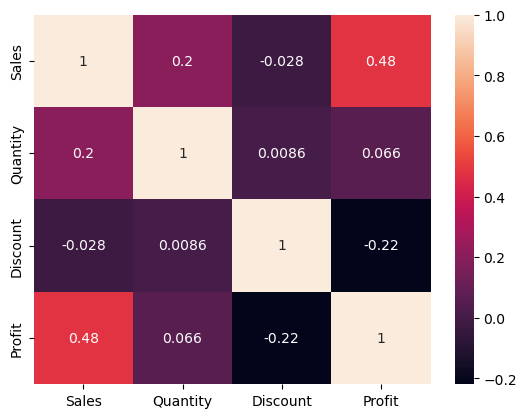

In [110]:
num_cols = ['Sales','Quantity','Discount','Profit']

sns.heatmap(df[num_cols].corr(), annot=True)

#### Hyphothesis testing
*H0* - Discount has no impact on Profit
*H1* - Discount has impact on Profit

In [111]:
import statsmodels.api as sm
import numpy as np

X = df[['Discount','Quantity','Sales']]
X = pd.get_dummies(
    df[['Discount','Quantity','Sales','Category','Region','Segment']],
    drop_first=True
)

y = df['Profit']
#x_names=['Discount','Quantity','Sales','Category','Region','Segment']
X = sm.add_constant(X)
# formula= y + '~' + '+'.join(x_names)
Y = y.astype(float)
x = X.astype(float)

model = sm.OLS(Y, x ).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     389.3
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:50:57   Log-Likelihood:                -67067.
No. Observations:                9994   AIC:                         1.342e+05
Df Residuals:                    9983   BIC:                         1.342e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

#### Hypothesis testing result from regression analysis
the null hypothesis *H0* is rejected since discount clearly has impact. it can be observed from **P-values** < 0.005 are features or predictors that contribute to profit drive.

### The End of EDA of Superstore Dataset

#### Key Drivers of Profit

- Region: West is the clear outperformer (highest margin, lowest loss rate, highest total profit contribution). Central is the biggest drag (negative avg margin, 31.9% loss rate).
- Segment: Home Office shows strongest margins and efficiency; Consumer dominates volume but lower per-order profitability.
- Discount: Strong negative relationship — higher discounts correlate with negative profit (visible in scatter).
- Category: Office Supplies dominates volume but Technology likely drives disproportionate profit (to be confirmed in multivariate).


#### Recommendations 
* Perform a Product Portfolio Rationalization. Furniture is currently consuming a disproportionate amount of 'Operational Gravity' (warehouse space and labor) for minimal profit return.

* The analysis shows that `Technology` is our most capital-efficient segment, yielding the highest profit despite representing the lowest physical volume. To maximize ROI, we should reallocate working capital from high-volume/loss-making categories (like Furniture) into `Technology`.
* Conduct a Best-Practice Audit of the `West` Region. This region should serve as the organizational benchmark for 'Commercial Excellence.'

* Given the high 'Return on Sales' and low loss rate, every dollar of customer acquisition spend in this territory yields a significantly higher net profit compared to other regions.

* The Central Region is currently operating at a negative net margin, acting as a primary drain on total Superstore profitability. I recommend an immediate Regional Pricing Audit.

* protect/grow `Consumer` volume while reducing loss rate,

* `Home Office` is a high-quality segment — consider targeted marketing / upselling here to increase share

* Tighten discount controls in Furniture (especially Central) to eliminate losses.  
* Invest in growing Technology share across all regions to leverage its superior economics.
* Cut discounting at **Low** level upto 20%. especially in `Technology`
* Before Implementing High Discount, Consult the Finance people
